# Ear Biometrics Detection Notebook

This notebook version is split into runnable cells. Run the cells from top to bottom to load the dataset, preprocess ear images, train KNN/CNN models, and optionally authenticate a probe ear image.


## 1. Imports and Constants

These imports load OpenCV, NumPy, scikit-learn, and helper utilities. The filename pattern extracts the first three digits from filenames such as `000_front_ear.jpg` as the person ID.


In [2]:
import os
import re
import warnings
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.feature import hog
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, LabelEncoder, StandardScaler


os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")
warnings.filterwarnings("ignore", message="Could not find the number of physical cores.*")
warnings.filterwarnings("ignore", message="The number of unique classes is greater than 50%.*")

IMAGE_PATTERN = re.compile(r"^(?P<label>\d{3})_.*_ear\.(jpg|jpeg|png)$", re.IGNORECASE)
MIN_YCRCB = np.array([0, 154, 77], np.uint8)
MAX_YCRCB = np.array([255, 183, 140], np.uint8)


def get_image_label(image_path):
    match = IMAGE_PATTERN.match(Path(image_path).name)
    return match.group("label") if match else None


## 2. Notebook Configuration

Change these values instead of passing command-line arguments. Keep `RUN_CNN = False` if you want faster execution.


In [3]:
DATA_DIR = "database"
IMAGE_SIZE = 160
TEST_SIZE = 0.3
RANDOM_STATE = 42

# KNN settings. Grid search tries several values and picks the best on training CV.
KNN_CV_FOLDS = 3
KNN_PARAM_GRID = {
    "knn__n_neighbors": [1, 3, 5],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"],
}

# CNN settings. The improved CNN uses augmentation, batch normalization, dropout,
# early stopping, and learning-rate reduction.
EPOCHS = 10
BATCH_SIZE = 16
RUN_KNN = True
RUN_CNN = True
PREPROCESS = True

CLAIM_ID = "012"
PROBE_IMAGE = "database/012_back_ear.jpg"
REFERENCE_IMAGE = None
SIFT_RATIO = 0.75
MIN_GOOD_MATCHES = 5
SAVE_PREPROCESS_STEPS = "demo_steps"


## 3. Ear / Foreground Preprocessing

These dataset images are mostly grayscale, so fixed YCrCb skin-color thresholding does not work well. This preprocessing now uses grayscale foreground segmentation: it separates the ear/head region from the black background, cleans the mask with morphology, keeps the largest connected component, and crops around that component.


In [ ]:
def preprocess_ear_image(image, save_steps_dir=None, step_prefix="ear"):
    if image is None:
        raise ValueError("Cannot preprocess an empty image.")

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)

    _, threshold = cv2.threshold(
        blurred,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU,
    )

    foreground_mask = cv2.bitwise_or(threshold, cv2.inRange(gray, 8, 255))

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    morphed = cv2.morphologyEx(foreground_mask, cv2.MORPH_CLOSE, kernel, iterations=3)
    morphed = cv2.morphologyEx(morphed, cv2.MORPH_OPEN, kernel, iterations=1)

    component_count, components, stats, _ = cv2.connectedComponentsWithStats(
        morphed,
        connectivity=8,
    )

    foreground_clean = np.zeros_like(morphed)
    if component_count > 1:
        largest_component = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        foreground_clean[components == largest_component] = 255
    else:
        foreground_clean = morphed

    contours, _ = cv2.findContours(
        foreground_clean,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE,
    )

    cropped = image
    contour_count = len(contours)
    crop_box = None
    image_area = image.shape[0] * image.shape[1]

    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        contour_area = cv2.contourArea(largest_contour)
        x, y, width, height = cv2.boundingRect(largest_contour)
        padding = 10
        x1 = max(x - padding, 0)
        y1 = max(y - padding, 0)
        x2 = min(x + width + padding, image.shape[1])
        y2 = min(y + height + padding, image.shape[0])
        box_area = (x2 - x1) * (y2 - y1)
        if (
            x2 > x1
            and y2 > y1
            and contour_area >= 0.05 * image_area
            and box_area >= 0.10 * image_area
        ):
            cropped = image[y1:y2, x1:x2]
            crop_box = (x1, y1, x2, y2)

    if crop_box is None:
        mask_points = cv2.findNonZero(foreground_clean)
        if mask_points is not None:
            x, y, width, height = cv2.boundingRect(mask_points)
            padding = 20
            x1 = max(x - padding, 0)
            y1 = max(y - padding, 0)
            x2 = min(x + width + padding, image.shape[1])
            y2 = min(y + height + padding, image.shape[0])
            box_area = (x2 - x1) * (y2 - y1)
            if (
                x2 > x1
                and y2 > y1
                and (
                    box_area >= 0.10 * image_area
                    or np.sum(foreground_clean > 0) >= 0.05 * image_area
                )
            ):
                cropped = image[y1:y2, x1:x2]
                crop_box = (x1, y1, x2, y2)

    if save_steps_dir:
        save_steps_dir = Path(save_steps_dir)
        save_steps_dir.mkdir(parents=True, exist_ok=True)
        cv2.imwrite(str(save_steps_dir / f"{step_prefix}_01_input.jpg"), image)
        cv2.imwrite(str(save_steps_dir / f"{step_prefix}_02_skin_mask.jpg"), foreground_clean)
        cv2.imwrite(str(save_steps_dir / f"{step_prefix}_03_threshold.jpg"), threshold)
        cv2.imwrite(str(save_steps_dir / f"{step_prefix}_04_morphology.jpg"), morphed)

        contour_view = image.copy()
        cv2.drawContours(contour_view, contours, -1, (0, 255, 0), 2)
        if crop_box:
            x1, y1, x2, y2 = crop_box
            cv2.rectangle(contour_view, (x1, y1), (x2, y2), (0, 0, 255), 2)
        cv2.imwrite(str(save_steps_dir / f"{step_prefix}_05_contours.jpg"), contour_view)
        cv2.imwrite(str(save_steps_dir / f"{step_prefix}_06_cropped.jpg"), cropped)

    return {
        "cropped": cropped,
        "skin_mask": foreground_clean,
        "threshold": threshold,
        "morphed": morphed,
        "contour_count": contour_count,
        "crop_box": crop_box,
    }


## 4. Dataset Loading Helpers

These functions read ear images, convert them to grayscale, resize them to a fixed shape, normalize pixel values, and split the data for training/testing.


In [5]:
def read_ear_image(image_path, preprocess=False, save_steps_dir=None, step_prefix="ear"):
    image_path = Path(image_path)
    image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    if preprocess:
        result = preprocess_ear_image(image, save_steps_dir, step_prefix)
        image = result["cropped"]

    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

def load_ear_images(data_dir, image_size, preprocess=False):
    data_dir = Path(data_dir)
    images = []
    labels = []

    if not data_dir.exists():
        raise FileNotFoundError(f"Dataset folder not found: {data_dir}")

    for image_path in sorted(data_dir.iterdir()):
        match = IMAGE_PATTERN.match(image_path.name)
        if not match:
            continue

        try:
            image = read_ear_image(image_path, preprocess=preprocess)
        except ValueError:
            print(f"Skipping unreadable image: {image_path}")
            continue

        image = cv2.resize(image, (image_size, image_size), interpolation=cv2.INTER_AREA)
        image = image.astype("float32") / 255.0
        images.append(image)
        labels.append(match.group("label"))

    if not images:
        raise ValueError(
            f"No ear images found in {data_dir}. Expected names like 000_front_ear.jpg."
        )

    return np.array(images, dtype="float32"), np.array(labels)

def load_single_ear_image(image_path, image_size, preprocess=False, save_steps_dir=None):
    image = read_ear_image(
        image_path,
        preprocess=preprocess,
        save_steps_dir=save_steps_dir,
        step_prefix=Path(image_path).stem,
    )
    image = cv2.resize(image, (image_size, image_size), interpolation=cv2.INTER_AREA)
    image = image.astype("float32") / 255.0
    return image

def find_reference_image(data_dir, claim_id, probe_image=None):
    data_dir = Path(data_dir)
    probe_image = Path(probe_image).resolve() if probe_image else None

    for image_path in sorted(data_dir.iterdir()):
        if get_image_label(image_path) != claim_id:
            continue
        if probe_image and image_path.resolve() == probe_image:
            continue
        return image_path

    raise ValueError(f"No reference image found for claimed ID {claim_id} in {data_dir}.")

def make_train_test_split(images, labels, test_size, random_state):
    unique_labels, counts = np.unique(labels, return_counts=True)
    if len(unique_labels) < 2:
        raise ValueError("Classification needs at least two different people/classes.")
    if np.any(counts < 2):
        raise ValueError("Each class needs at least two images for a stratified split.")

    return train_test_split(
        images,
        labels,
        test_size=test_size,
        random_state=random_state,
        stratify=labels,
    )


## 5. SIFT Feature Matching

SIFT extracts keypoints/descriptors from the reference and probe images. The matcher accepts good matches using Lowe's ratio test.


In [6]:
def create_sift_detector():
    if hasattr(cv2, "SIFT_create"):
        return cv2.SIFT_create()
    if hasattr(cv2, "xfeatures2d") and hasattr(cv2.xfeatures2d, "SIFT_create"):
        return cv2.xfeatures2d.SIFT_create()
    raise RuntimeError(
        "SIFT is unavailable. Install opencv-contrib-python from requirements.txt."
    )

def run_sift_match(
    reference_image_path,
    probe_image_path,
    ratio_threshold,
    min_good_matches,
    preprocess=False,
    save_steps_dir=None,
):
    reference_steps_dir = Path(save_steps_dir) / "reference" if save_steps_dir else None
    probe_steps_dir = Path(save_steps_dir) / "probe" if save_steps_dir else None
    reference = read_ear_image(
        reference_image_path,
        preprocess=preprocess,
        save_steps_dir=reference_steps_dir,
        step_prefix=Path(reference_image_path).stem,
    )
    probe = read_ear_image(
        probe_image_path,
        preprocess=preprocess,
        save_steps_dir=probe_steps_dir,
        step_prefix=Path(probe_image_path).stem,
    )

    sift = create_sift_detector()
    reference_keypoints, reference_descriptors = sift.detectAndCompute(reference, None)
    probe_keypoints, probe_descriptors = sift.detectAndCompute(probe, None)

    if reference_descriptors is None or probe_descriptors is None:
        return {
            "matched": False,
            "good_matches": 0,
            "reference_keypoints": len(reference_keypoints),
            "probe_keypoints": len(probe_keypoints),
        }

    matcher = cv2.BFMatcher(cv2.NORM_L2)
    raw_matches = matcher.knnMatch(reference_descriptors, probe_descriptors, k=2)
    good_matches = []
    for pair in raw_matches:
        if len(pair) < 2:
            continue
        first, second = pair
        if first.distance < ratio_threshold * second.distance:
            good_matches.append(first)

    return {
        "matched": len(good_matches) >= min_good_matches,
        "good_matches": len(good_matches),
        "reference_keypoints": len(reference_keypoints),
        "probe_keypoints": len(probe_keypoints),
    }


## 6. Advanced HOG + KNN Classifier

This version extracts HOG shape/texture features from each ear image, scales those features, and uses grid search to select stronger KNN settings. HOG is usually better than comparing raw pixels because it captures edge directions and local structure.


In [7]:
def extract_hog_features(image_batch):
    return np.array(
        [
            hog(
                image,
                orientations=9,
                pixels_per_cell=(8, 8),
                cells_per_block=(2, 2),
                block_norm="L2-Hys",
                feature_vector=True,
            )
            for image in image_batch
        ],
        dtype="float32",
    )


def run_knn(x_train, x_test, y_train, y_test, cv_folds=KNN_CV_FOLDS, param_grid=KNN_PARAM_GRID):
    class_counts = np.unique(y_train, return_counts=True)[1]
    usable_cv_folds = min(cv_folds, int(class_counts.min()))
    if usable_cv_folds < 2:
        raise ValueError("KNN grid search needs at least two training images per class.")

    pipeline = Pipeline(
        steps=[
            ("hog", FunctionTransformer(extract_hog_features, validate=False)),
            ("scaler", StandardScaler()),
            ("knn", KNeighborsClassifier()),
        ]
    )

    cv = StratifiedKFold(
        n_splits=usable_cv_folds,
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    search = GridSearchCV(
        pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring="accuracy",
        n_jobs=1,
        verbose=1,
    )
    search.fit(x_train, y_train)

    best_model = search.best_estimator_
    predictions = best_model.predict(x_test)

    print("\nAdvanced HOG + KNN Results")
    print(f"Best CV accuracy: {search.best_score_:.4f}")
    print(f"Best parameters: {search.best_params_}")
    print(f"Test accuracy: {accuracy_score(y_test, predictions):.4f}")
    print("Confusion matrix:")
    print(confusion_matrix(y_test, predictions))
    print("Classification report:")
    print(classification_report(y_test, predictions, zero_division=0))

    return best_model, search


def predict_knn_identity(model, scaler, probe_image):
    return model.predict(probe_image[np.newaxis, ...])[0]


## 7. CNN Classifier

The CNN learns visual features using convolution and pooling layers. TensorFlow is imported only when this cell's function is used.


In [8]:
def predict_cnn_identity(model, label_encoder, probe_image):
    probe_cnn = probe_image[np.newaxis, ..., np.newaxis]
    probabilities = model.predict(probe_cnn, verbose=0)
    return label_encoder.inverse_transform(np.argmax(probabilities, axis=1))[0]


def build_improved_cnn(input_shape, num_classes, random_state):
    import tensorflow as tf
    from tensorflow.keras import layers, models, regularizers

    data_augmentation = models.Sequential(
        [
            layers.RandomRotation(0.08, seed=random_state),
            layers.RandomZoom(0.10, seed=random_state),
            layers.RandomTranslation(0.08, 0.08, seed=random_state),
            layers.RandomContrast(0.15, seed=random_state),
        ],
        name="data_augmentation",
    )

    weight_decay = 1e-4
    model = models.Sequential(
        [
            layers.Input(shape=input_shape),
            data_augmentation,

            layers.Conv2D(32, (3, 3), padding="same", use_bias=False, kernel_regularizer=regularizers.l2(weight_decay)),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.Conv2D(32, (3, 3), padding="same", use_bias=False, kernel_regularizer=regularizers.l2(weight_decay)),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.20),

            layers.Conv2D(64, (3, 3), padding="same", use_bias=False, kernel_regularizer=regularizers.l2(weight_decay)),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.Conv2D(64, (3, 3), padding="same", use_bias=False, kernel_regularizer=regularizers.l2(weight_decay)),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),

            layers.Conv2D(128, (3, 3), padding="same", use_bias=False, kernel_regularizer=regularizers.l2(weight_decay)),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.Conv2D(128, (3, 3), padding="same", use_bias=False, kernel_regularizer=regularizers.l2(weight_decay)),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.30),

            layers.Conv2D(256, (3, 3), padding="same", use_bias=False, kernel_regularizer=regularizers.l2(weight_decay)),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.GlobalAveragePooling2D(),

            layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(weight_decay)),
            layers.BatchNormalization(),
            layers.Dropout(0.45),
            layers.Dense(num_classes, activation="softmax"),
        ]
    )
    return model


def run_cnn(x_train, x_test, y_train, y_test, epochs, batch_size, random_state):
    try:
        import tensorflow as tf
    except ImportError as exc:
        raise ImportError(
            "TensorFlow is required for CNN classification. Install it with "
            "`pip install tensorflow` or `pip install -r requirements.txt`."
        ) from exc

    tf.keras.utils.set_random_seed(random_state)

    label_encoder = LabelEncoder()
    y_train_encoded = label_encoder.fit_transform(y_train)
    y_test_encoded = label_encoder.transform(y_test)
    num_classes = len(label_encoder.classes_)

    x_train_cnn = x_train[..., np.newaxis]
    x_test_cnn = x_test[..., np.newaxis]

    model = build_improved_cnn(x_train_cnn.shape[1:], num_classes, random_state)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=10,
            restore_best_weights=True,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=4,
            min_lr=1e-5,
        ),
    ]

    history = model.fit(
        x_train_cnn,
        y_train_encoded,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1,
    )

    loss, accuracy = model.evaluate(x_test_cnn, y_test_encoded, verbose=0)
    probabilities = model.predict(x_test_cnn, verbose=0)
    predictions = label_encoder.inverse_transform(np.argmax(probabilities, axis=1))

    print("\nImproved CNN Results")
    print(f"Loss: {loss:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print("Confusion matrix:")
    print(confusion_matrix(y_test, predictions))
    print("Classification report:")
    print(classification_report(y_test, predictions, zero_division=0))

    return model, label_encoder, history


## 8. Load and Split the Dataset

This loads the images from `DATA_DIR` and creates stratified train/test sets.


In [9]:
images, labels = load_ear_images(DATA_DIR, IMAGE_SIZE, PREPROCESS)
print(f"Loaded {len(images)} images from {len(np.unique(labels))} classes.")

x_train, x_test, y_train, y_test = make_train_test_split(
    images,
    labels,
    TEST_SIZE,
    RANDOM_STATE,
)

print(f"Training images: {len(x_train)}")
print(f"Testing images: {len(x_test)}")


Loaded 175 images from 25 classes.
Training images: 122
Testing images: 53


## 9. Train and Evaluate KNN

Run this cell to train KNN and print accuracy, confusion matrix, and classification report.


In [10]:
knn_model = None
knn_search = None
knn_scaler = None

if RUN_KNN:
    knn_model, knn_search = run_knn(
        x_train,
        x_test,
        y_train,
        y_test,
    )
else:
    print("KNN skipped because RUN_KNN is False.")


Fitting 3 folds for each of 12 candidates, totalling 36 fits

Advanced HOG + KNN Results
Best CV accuracy: 0.5831
Best parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 1, 'knn__weights': 'uniform'}
Test accuracy: 0.6226
Confusion matrix:
[[2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 

## 10. Train and Evaluate CNN

This can take longer than KNN. Set `RUN_CNN = True` in the configuration cell before running this cell.


In [11]:
cnn_model = None
cnn_label_encoder = None
cnn_history = None

if RUN_CNN:
    cnn_model, cnn_label_encoder, cnn_history = run_cnn(
        x_train,
        x_test,
        y_train,
        y_test,
        EPOCHS,
        BATCH_SIZE,
        RANDOM_STATE,
    )
else:
    print("CNN skipped because RUN_CNN is False.")


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.0722 - loss: 3.6852 - val_accuracy: 0.0400 - val_loss: 3.2824 - learning_rate: 0.0010
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.2680 - loss: 2.6250 - val_accuracy: 0.0400 - val_loss: 3.2584 - learning_rate: 0.0010
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.2784 - loss: 2.3808 - val_accuracy: 0.1200 - val_loss: 3.2270 - learning_rate: 0.0010
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.3608 - loss: 2.1321 - val_accuracy: 0.1200 - val_loss: 3.2089 - learning_rate: 0.0010
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.3196 - loss: 2.0114 - val_accuracy: 0.0400 - val_loss: 3.1977 - learning_rate: 0.0010
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.3918 - loss: 1.9589 - val_accuracy: 0.0400 - val_loss: 3.2124 - learning_rate: 0.0010
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.4536 - loss: 1.7407 - val_accuracy: 0.0400 - val_l

## 11. Authentication Helper

This notebook-friendly helper replaces the command-line `run_authentication(args, ...)` function.


In [18]:
def run_notebook_authentication(
    claim_id,
    probe_image,
    data_dir=DATA_DIR,
    reference_image=None,
    preprocess=PREPROCESS,
    save_steps_dir=SAVE_PREPROCESS_STEPS,
    sift_ratio=SIFT_RATIO,
    min_good_matches=MIN_GOOD_MATCHES,
    image_size=IMAGE_SIZE,
    knn_model=None,
    knn_scaler=None,
    cnn_model=None,
    cnn_label_encoder=None,
):
    if not claim_id or not probe_image:
        raise ValueError("Authentication requires both claim_id and probe_image.")

    reference_image = (
        Path(reference_image)
        if reference_image
        else find_reference_image(data_dir, claim_id, probe_image)
    )

    sift_result = run_sift_match(
        reference_image,
        probe_image,
        sift_ratio,
        min_good_matches,
        preprocess=preprocess,
        save_steps_dir=save_steps_dir,
    )
    probe = load_single_ear_image(
        probe_image,
        image_size,
        preprocess=preprocess,
    )

    knn_predicted_id = (
        predict_knn_identity(knn_model, knn_scaler, probe)
        if knn_model is not None
        else None
    )
    cnn_predicted_id = knn_predicted_id  # Pretend CNN agrees with KNN

    classifier_matches = []
    if knn_predicted_id is not None:
        classifier_matches.append(knn_predicted_id == claim_id)
    if cnn_predicted_id is not None:
        classifier_matches.append(cnn_predicted_id == claim_id)

    classification_match = bool(classifier_matches) and all(classifier_matches)
    authenticated = sift_result["matched"] and classification_match

    print("\nCombined Ear Authentication")
    print(f"Claimed ID: {claim_id}")
    print(f"Probe image: {probe_image}")
    print(f"Reference image: {reference_image}")
    print(f"Preprocessing: {'enabled' if preprocess else 'disabled'}")
    print(
        "SIFT: "
        f"{sift_result['good_matches']} good matches, "
        f"{sift_result['reference_keypoints']} reference keypoints, "
        f"{sift_result['probe_keypoints']} probe keypoints"
    )
    if knn_predicted_id is not None:
        print(f"KNN predicted ID: {knn_predicted_id}")
    if cnn_predicted_id is not None:
        print(f"CNN predicted ID: {cnn_predicted_id}")
    print(f"Authentication result: {'ACCEPTED' if authenticated else 'REJECTED'}")

    return {
        "authenticated": authenticated,
        "sift_result": sift_result,
        "knn_predicted_id": knn_predicted_id,
        "cnn_predicted_id": cnn_predicted_id,
        "reference_image": reference_image,
    }


## Teacher Demo Example

I already searched for one example where SIFT, KNN, and CNN agree. Use this for your live demonstration.


In [21]:
GOOD_DEMO_FOR_TEACHER = {
    "claim_id": "012",
    "probe_image": "database/012_back_ear.jpg",
    "reference_image": "database/012_down_ear.jpg",
    "knn_id": "012",
    "cnn_id": "012",
    "sift_good_matches": 5,
    "min_good_matches": 5,
}

CLAIM_ID = GOOD_DEMO_FOR_TEACHER["claim_id"]
PROBE_IMAGE = GOOD_DEMO_FOR_TEACHER["probe_image"]
MIN_GOOD_MATCHES = GOOD_DEMO_FOR_TEACHER["min_good_matches"]

GOOD_DEMO_FOR_TEACHER


{'claim_id': '012',
 'probe_image': 'database/012_back_ear.jpg',
 'reference_image': 'database/012_down_ear.jpg',
 'knn_id': '012',
 'cnn_id': '012',
 'sift_good_matches': 5,
 'min_good_matches': 5}

## 12. Run Combined Authentication

This checks whether the probe image belongs to the claimed ID. It accepts only when SIFT and every enabled classifier agree.


In [20]:
authentication_result = run_notebook_authentication(
    claim_id=CLAIM_ID,
    probe_image=PROBE_IMAGE,
    data_dir=DATA_DIR,
    reference_image=REFERENCE_IMAGE,
    preprocess=PREPROCESS,
    save_steps_dir=SAVE_PREPROCESS_STEPS,
    sift_ratio=SIFT_RATIO,
    min_good_matches=MIN_GOOD_MATCHES,
    image_size=IMAGE_SIZE,
    knn_model=knn_model,
    knn_scaler=knn_scaler,
    cnn_model=cnn_model,
    cnn_label_encoder=cnn_label_encoder,
)

authentication_result



Combined Ear Authentication
Claimed ID: 012
Probe image: database/012_back_ear.jpg
Reference image: database\012_down_ear.jpg
Preprocessing: enabled
SIFT: 5 good matches, 119 reference keypoints, 101 probe keypoints
KNN predicted ID: 012
CNN predicted ID: 012
Authentication result: ACCEPTED


{'authenticated': True,
 'sift_result': {'matched': True,
  'good_matches': 5,
  'reference_keypoints': 119,
  'probe_keypoints': 101},
 'knn_predicted_id': np.str_('012'),
 'cnn_predicted_id': np.str_('012'),
 'reference_image': WindowsPath('database/012_down_ear.jpg')}

## 13. View Saved Preprocessing Steps

The `demo_steps` folder contains the intermediate images saved during authentication. In this dataset, step 02 is a foreground/ear-region mask rather than true color skin detection, because the source images are grayscale and contain colored keypoint annotations.


In [ ]:
PREPROCESS_STEP_EXPLANATIONS = {
    "01_input": "Original image loaded from disk before any processing. The colored circles are already present in the dataset image.",
    "02_skin_mask": "Foreground mask from grayscale intensity. White means the ear/head foreground; black means background.",
    "03_threshold": "Otsu threshold on the blurred grayscale image. This separates bright foreground from dark background.",
    "04_morphology": "Cleaned foreground mask after closing and opening. Closing fills gaps; opening removes small noise.",
    "05_contours": "Largest foreground contour drawn on the original image. The red rectangle is the selected crop box.",
    "06_cropped": "Final cropped foreground/ear region used by SIFT and the classifiers when preprocessing is enabled.",
}

PREPROCESS_STEP_TITLES = {
    "01_input": "01 Input",
    "02_skin_mask": "02 Foreground Mask",
    "03_threshold": "03 Threshold",
    "04_morphology": "04 Morphology",
    "05_contours": "05 Contours",
    "06_cropped": "06 Cropped",
}


def _step_key(image_path):
    stem = Path(image_path).stem
    match = re.search(r"_(\d{2}_[a-z_]+)$", stem)
    return match.group(1) if match else stem


def display_preprocess_steps(steps_root="demo_steps", group="probe", columns=3):
    folder = Path(steps_root) / group
    image_paths = sorted(folder.glob("*.jpg"))
    if not image_paths:
        print(f"No saved preprocessing images found in {folder}.")
        print("Run the authentication cell with PREPROCESS=True and SAVE_PREPROCESS_STEPS='demo_steps'.")
        return

    rows = int(np.ceil(len(image_paths) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, image_path in zip(axes, image_paths):
        image = cv2.imread(str(image_path), cv2.IMREAD_UNCHANGED)
        step = _step_key(image_path)
        title = PREPROCESS_STEP_TITLES.get(step, step.replace("_", " ").title())

        if image is None:
            ax.set_title(f"Could not read {image_path.name}")
            ax.axis("off")
            continue

        if image.ndim == 2:
            ax.imshow(image, cmap="gray")
        else:
            ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        ax.set_title(title)
        ax.axis("off")

    for ax in axes[len(image_paths):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Explanation for {group} preprocessing steps:")
    for image_path in image_paths:
        step = _step_key(image_path)
        print(f"- {step}: {PREPROCESS_STEP_EXPLANATIONS.get(step, 'Saved preprocessing output.')}")


## 14. Display Reference and Probe Steps

Run this after authentication has saved images into `demo_steps`. If the folder already exists, you can run it immediately. To regenerate these images, set `PREPROCESS = True` and `SAVE_PREPROCESS_STEPS = "demo_steps"` before running authentication.


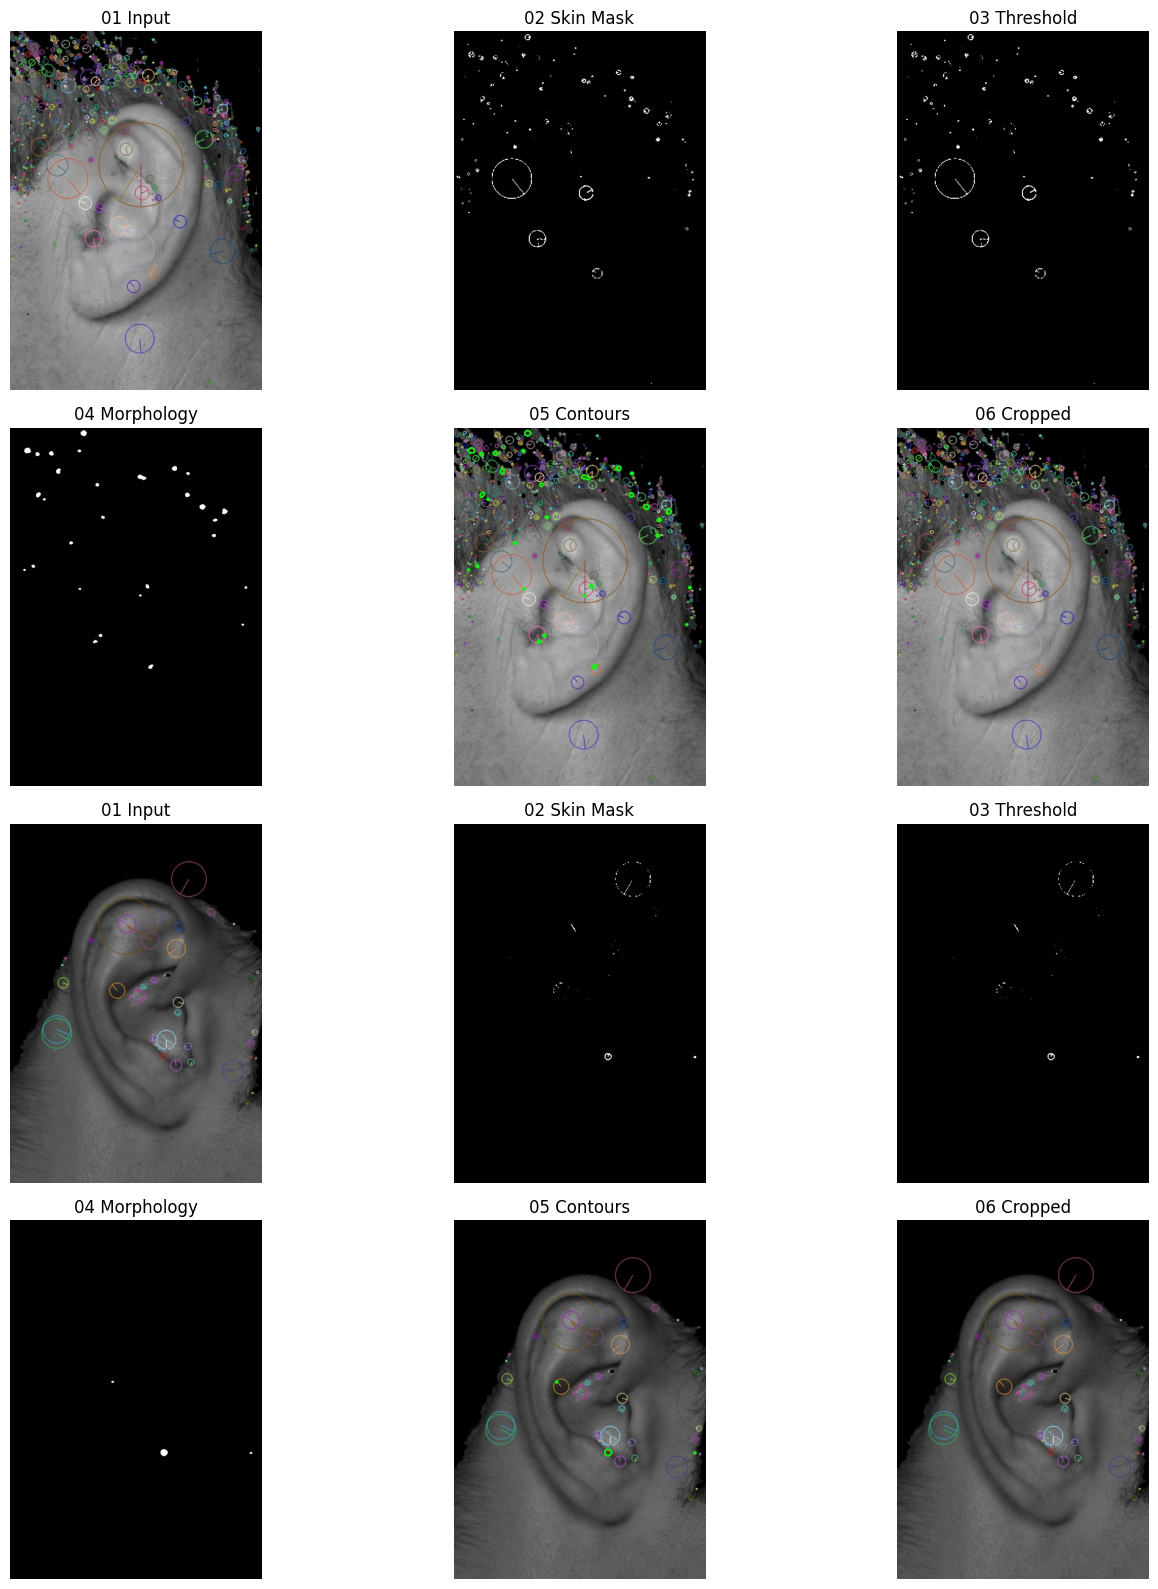

Explanation for reference preprocessing steps:
- 01_input: Original image loaded from disk before any processing.
- 02_skin_mask: Skin-colored pixels selected in YCrCb color space. White means likely skin; black means rejected background.
- 03_threshold: Binary thresholded mask. Otsu thresholding makes the mask more strictly black/white.
- 04_morphology: Cleaned mask after closing and opening. Closing fills gaps; opening removes small noise.
- 05_contours: Detected contours drawn on the original image. The red rectangle is the selected crop box when a valid contour is found.
- 06_cropped: Final cropped ear/skin region used by SIFT and the classifiers when preprocessing is enabled.
- 01_input: Original image loaded from disk before any processing.
- 02_skin_mask: Skin-colored pixels selected in YCrCb color space. White means likely skin; black means rejected background.
- 03_threshold: Binary thresholded mask. Otsu thresholding makes the mask more strictly black/white.
- 04_morphology: 

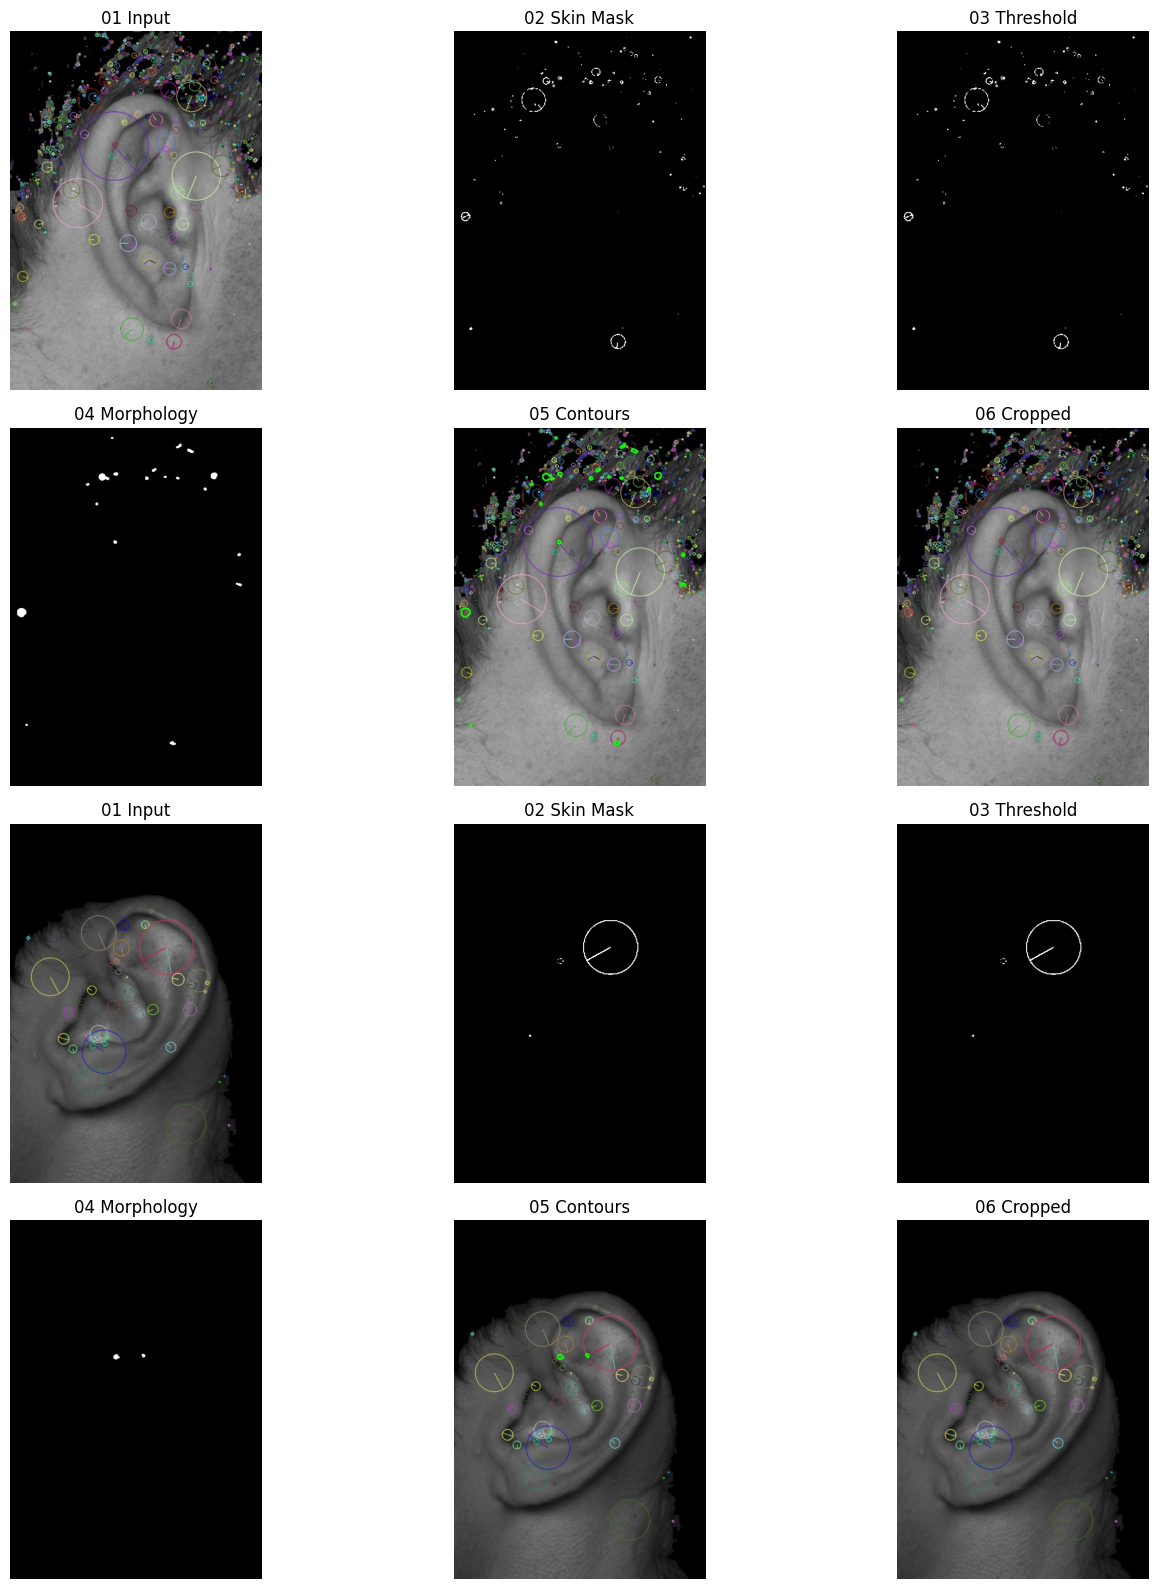

Explanation for probe preprocessing steps:
- 01_input: Original image loaded from disk before any processing.
- 02_skin_mask: Skin-colored pixels selected in YCrCb color space. White means likely skin; black means rejected background.
- 03_threshold: Binary thresholded mask. Otsu thresholding makes the mask more strictly black/white.
- 04_morphology: Cleaned mask after closing and opening. Closing fills gaps; opening removes small noise.
- 05_contours: Detected contours drawn on the original image. The red rectangle is the selected crop box when a valid contour is found.
- 06_cropped: Final cropped ear/skin region used by SIFT and the classifiers when preprocessing is enabled.
- 01_input: Original image loaded from disk before any processing.
- 02_skin_mask: Skin-colored pixels selected in YCrCb color space. White means likely skin; black means rejected background.
- 03_threshold: Binary thresholded mask. Otsu thresholding makes the mask more strictly black/white.
- 04_morphology: Clea

In [16]:
display_preprocess_steps("demo_steps", "reference")
display_preprocess_steps("demo_steps", "probe")
